KeyError: 'input'

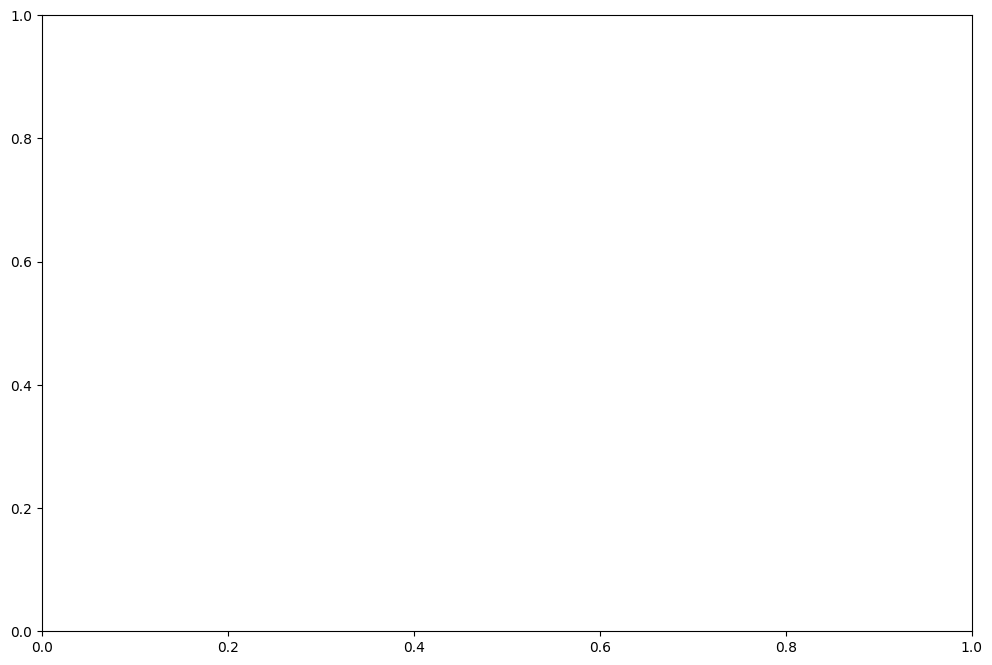

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, FancyArrowPatch, Circle

# Create a new figure with a white background
fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')

# Define colors
colors = {
    'embeddings': '#ffcc99',
    'attention': '#99ccff',
    'convolution': '#ccff99',
    'projection': '#cc99ff',
    'output': '#ff9999',
    'arrow': '#666666'
}

# Helper function to draw a module box
def draw_module(x, y, width, height, name, color, fontsize=10):
    rect = Rectangle((x, y), width, height, facecolor=color, edgecolor='black', alpha=0.7)
    ax.add_patch(rect)
    ax.text(x + width/2, y + height/2, name, ha='center', va='center', fontsize=fontsize, fontweight='bold')

# Helper function to draw an arrow
def draw_arrow(x1, y1, x2, y2, label=None):
    arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->', color=colors['arrow'], 
                          linewidth=1.5, connectionstyle='arc3,rad=0.1')
    ax.add_patch(arrow)
    if label:
        midx = (x1 + x2) / 2
        midy = (y1 + y2) / 2
        ax.text(midx, midy, label, ha='center', va='center', fontsize=8, 
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Draw modules
# Input section
draw_module(1, 9, 2, 0.8, "half_life", colors['input'], 9)
draw_module(1, 7, 2, 0.8, "DNA_Ordinal", colors['input'], 9)
draw_module(1, 5, 2, 0.8, "DNA_One_hot", colors['input'], 9)

# Embedding and projection modules
draw_module(4, 9, 3, 0.8, "MRNAProjection", colors['projection'], 9)
draw_module(4, 7, 3, 0.8, "Embedding_layer", colors['embeddings'], 9)

# Decoder and attention modules
draw_module(8, 8, 3, 1.5, "Percevier_Decoder", colors['attention'], 9)
draw_module(4, 5, 3, 0.8, "conv1d_attention", colors['convolution'], 9)
draw_module(4, 3, 3, 0.8, "N_Convo_attention", colors['convolution'], 9)
draw_module(8, 4, 3, 1.5, "Encoder_Decoder_Head\n(conv_attention_decoder)", colors['attention'], 8)

# Final processing modules
draw_module(12, 6, 2, 0.8, "Concat + FCL", colors['output'], 9)

# Draw arrows
draw_arrow(3, 9.4, 4, 9.4)
draw_arrow(3, 7.4, 4, 7.4)
draw_arrow(3, 5.4, 4, 5.4)

draw_arrow(7, 9.4, 8, 8.75, "Expanded_Half_Life")
draw_arrow(7, 7.4, 8, 8.25, "DNA_position_embeddings")

draw_arrow(11, 8.75, 12, 6.4, "averaged_Contextual_embeddings")

draw_arrow(7, 5.4, 4, 3.4)
draw_arrow(7, 3.4, 8, 4.75)
draw_arrow(11, 8.25, 8, 4.25, "DNA_contextual_embeddings")
draw_arrow(11, 4.75, 12, 6.0)

draw_arrow(14, 6.4, 15, 6.4, "final_logits")

# Add title and remove axes
ax.set_title('Perceiver Architecture for DNA and RNA Analysis', fontsize=14, fontweight='bold')
ax.axis('off')

# Set limits
ax.set_xlim(0, 16)
ax.set_ylim(2, 11)

# Add legend
legend_elements = [
    Rectangle((0, 0), 1, 1, facecolor=colors['input'], edgecolor='black', alpha=0.7, label='Input'),
    Rectangle((0, 0), 1, 1, facecolor=colors['embeddings'], edgecolor='black', alpha=0.7, label='Embeddings'),
    Rectangle((0, 0), 1, 1, facecolor=colors['attention'], edgecolor='black', alpha=0.7, label='Attention'),
    Rectangle((0, 0), 1, 1, facecolor=colors['convolution'], edgecolor='black', alpha=0.7, label='Convolution'),
    Rectangle((0, 0), 1, 1, facecolor=colors['projection'], edgecolor='black', alpha=0.7, label='Projection'),
    Rectangle((0, 0), 1, 1, facecolor=colors['output'], edgecolor='black', alpha=0.7, label='Output')
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.05), ncol=3)

plt.tight_layout()
plt.show()